# Explanation

This notebook attempts to test a hypothesis on  decision tree "move forward at a road intersection, given that the light has just turned green."

There is some lack of proper measuring and the plots mostly are used to help visualize relationships between the generate synthetic data.

The goal was simply to show how a few features (e.g. green light and temperature) impacts the decision to move or stay put. 

Proper measuring will likely require further work to split & normalize/standarize datasets,train/fit/validate and measure the loss, and finally attempt to measure optimizing the least loss based on data and the training hyperparameters.  

# Setup


In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

import dtreeviz

# Generate 100 rows of fake data where 
# green_light probability matches move_forward probability on purpose
# to indicate direct correlation between the two features
data = {
    'green_light': np.random.choice([0, 1], size=100, p=[0.2, 0.8]),  # 0=No, 1=Yes
    'Temperature': np.random.randint(40, 95, size=100),
}
df = pd.DataFrame(data)

# Generate 100 rows for target: 20% chance of '0' stay put, 80% chance of '1' move forward
df['move_forward'] = np.random.choice([0, 1], size=100, p=[0.2, 0.8])

X = df[['green_light', 'Temperature']]
y = df['move_forward']


display(df.head())
display(X.head())


,green_light,Temperature,move_forward
0,1,58,1
1,1,66,1
2,1,82,1
3,1,93,1
4,1,74,1


,green_light,Temperature
0,1,58
1,1,66
2,1,82
3,1,93
4,1,74


# Train

In [56]:
# Initialize and train the model
clf = DecisionTreeClassifier(max_depth=3)
# clf.fit(df[['green_light', 'Temperature']], df['move_forward'])
clf.fit(X, y)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

## Viz via plot_tree

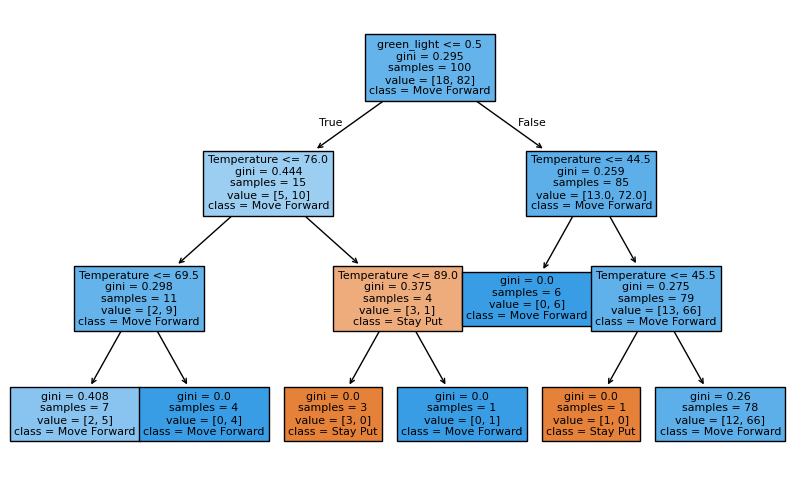

In [57]:
# Visualize the tree
plt.figure(figsize=(10, 6))
plot_tree(clf, feature_names=['green_light', 'Temperature'], 
          class_names=['Stay Put', 'Move Forward'], filled=True)
plt.show()


## Visual via dtreeviz

/Users/aricode0/devML/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


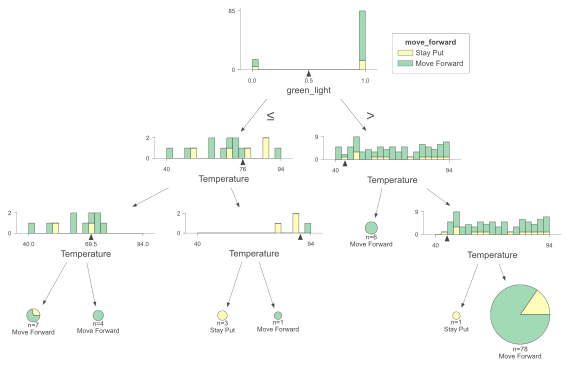

In [37]:
viz_model = dtreeviz.model(clf,
                          X_train=X, y_train=y,
                          feature_names=['green_light', 'Temperature'],
                          target_name='move_forward',
                          class_names=['Stay Put', 'Move Forward'])

# viz_model.view(scale=0.8)
viz_model.view()
# v.show()                 # pop up window

# Feature Importance on a Single Sample

Its likely the results from this step output high variance due to the distribution of temp out weighting the green light of 1 or 0. Normalizing will likely improve this but more research and heuristics will be required to confirm as well as the math and statistical foundations.

In [58]:
# x_10 = X.iloc[10].to_numpy().reshape(1, -1)
x_10 = X.iloc[10].to_numpy()
x_10

array([ 1, 93])

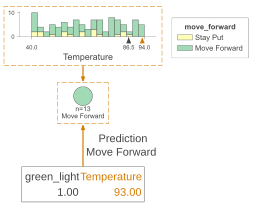

In [59]:
viz_model.view(x=x_10, show_just_path=True)

## Feature Importance

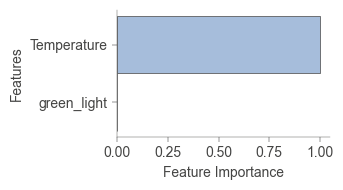

In [47]:
viz_model.instance_feature_importance(x=x_10, figsize=(3.5,2))

# Train & Viz & Score on multiple data scenarios

,seed,p_green,p_move,max_depth,train_accuracy
0,0,0.10,0.8,3.0,0.79
1,7,0.20,0.7,3.0,0.79
2,21,0.35,0.6,4.0,0.59
3,21,0.50,0.5,4.0,0.67
4,21,0.80,0.8,4.0,0.83
5,21,0.80,0.8,NaN,0.92


/Users/aricode0/devML/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


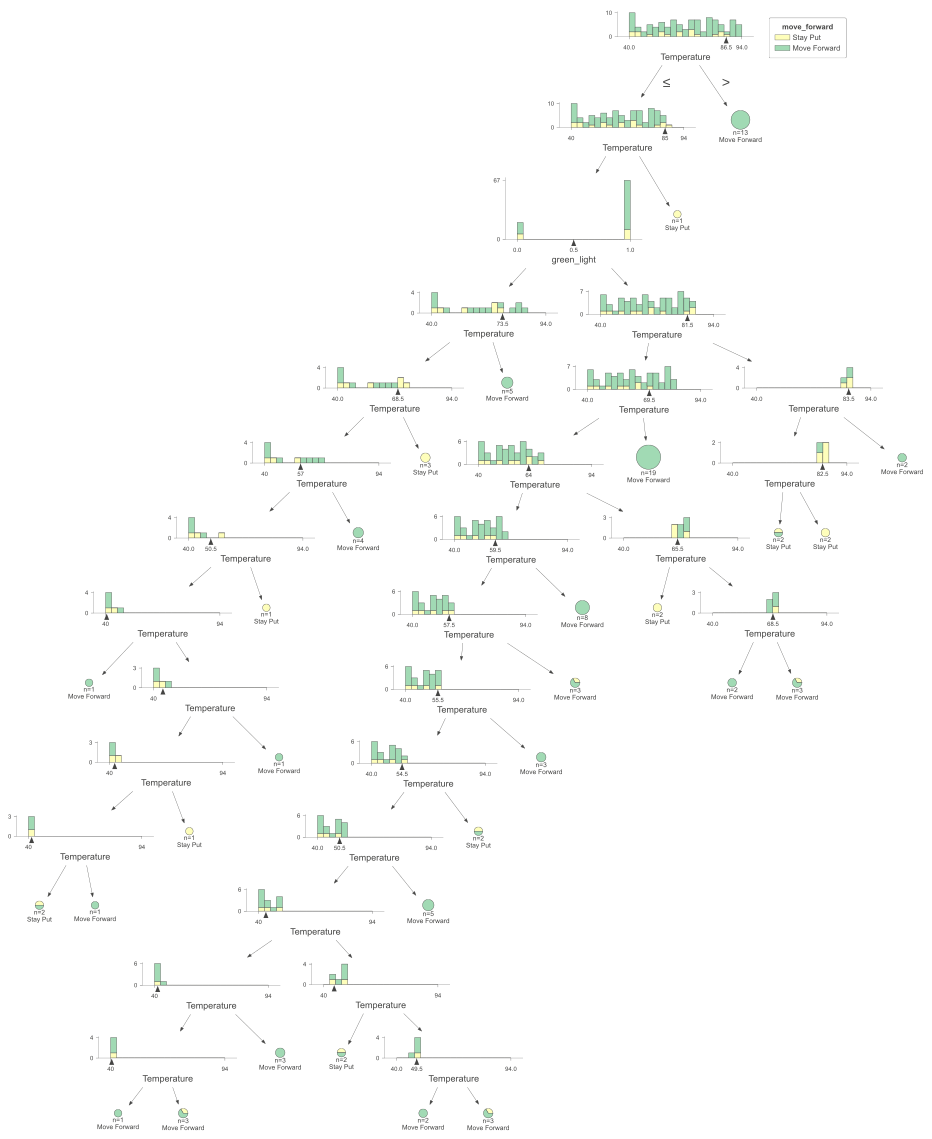

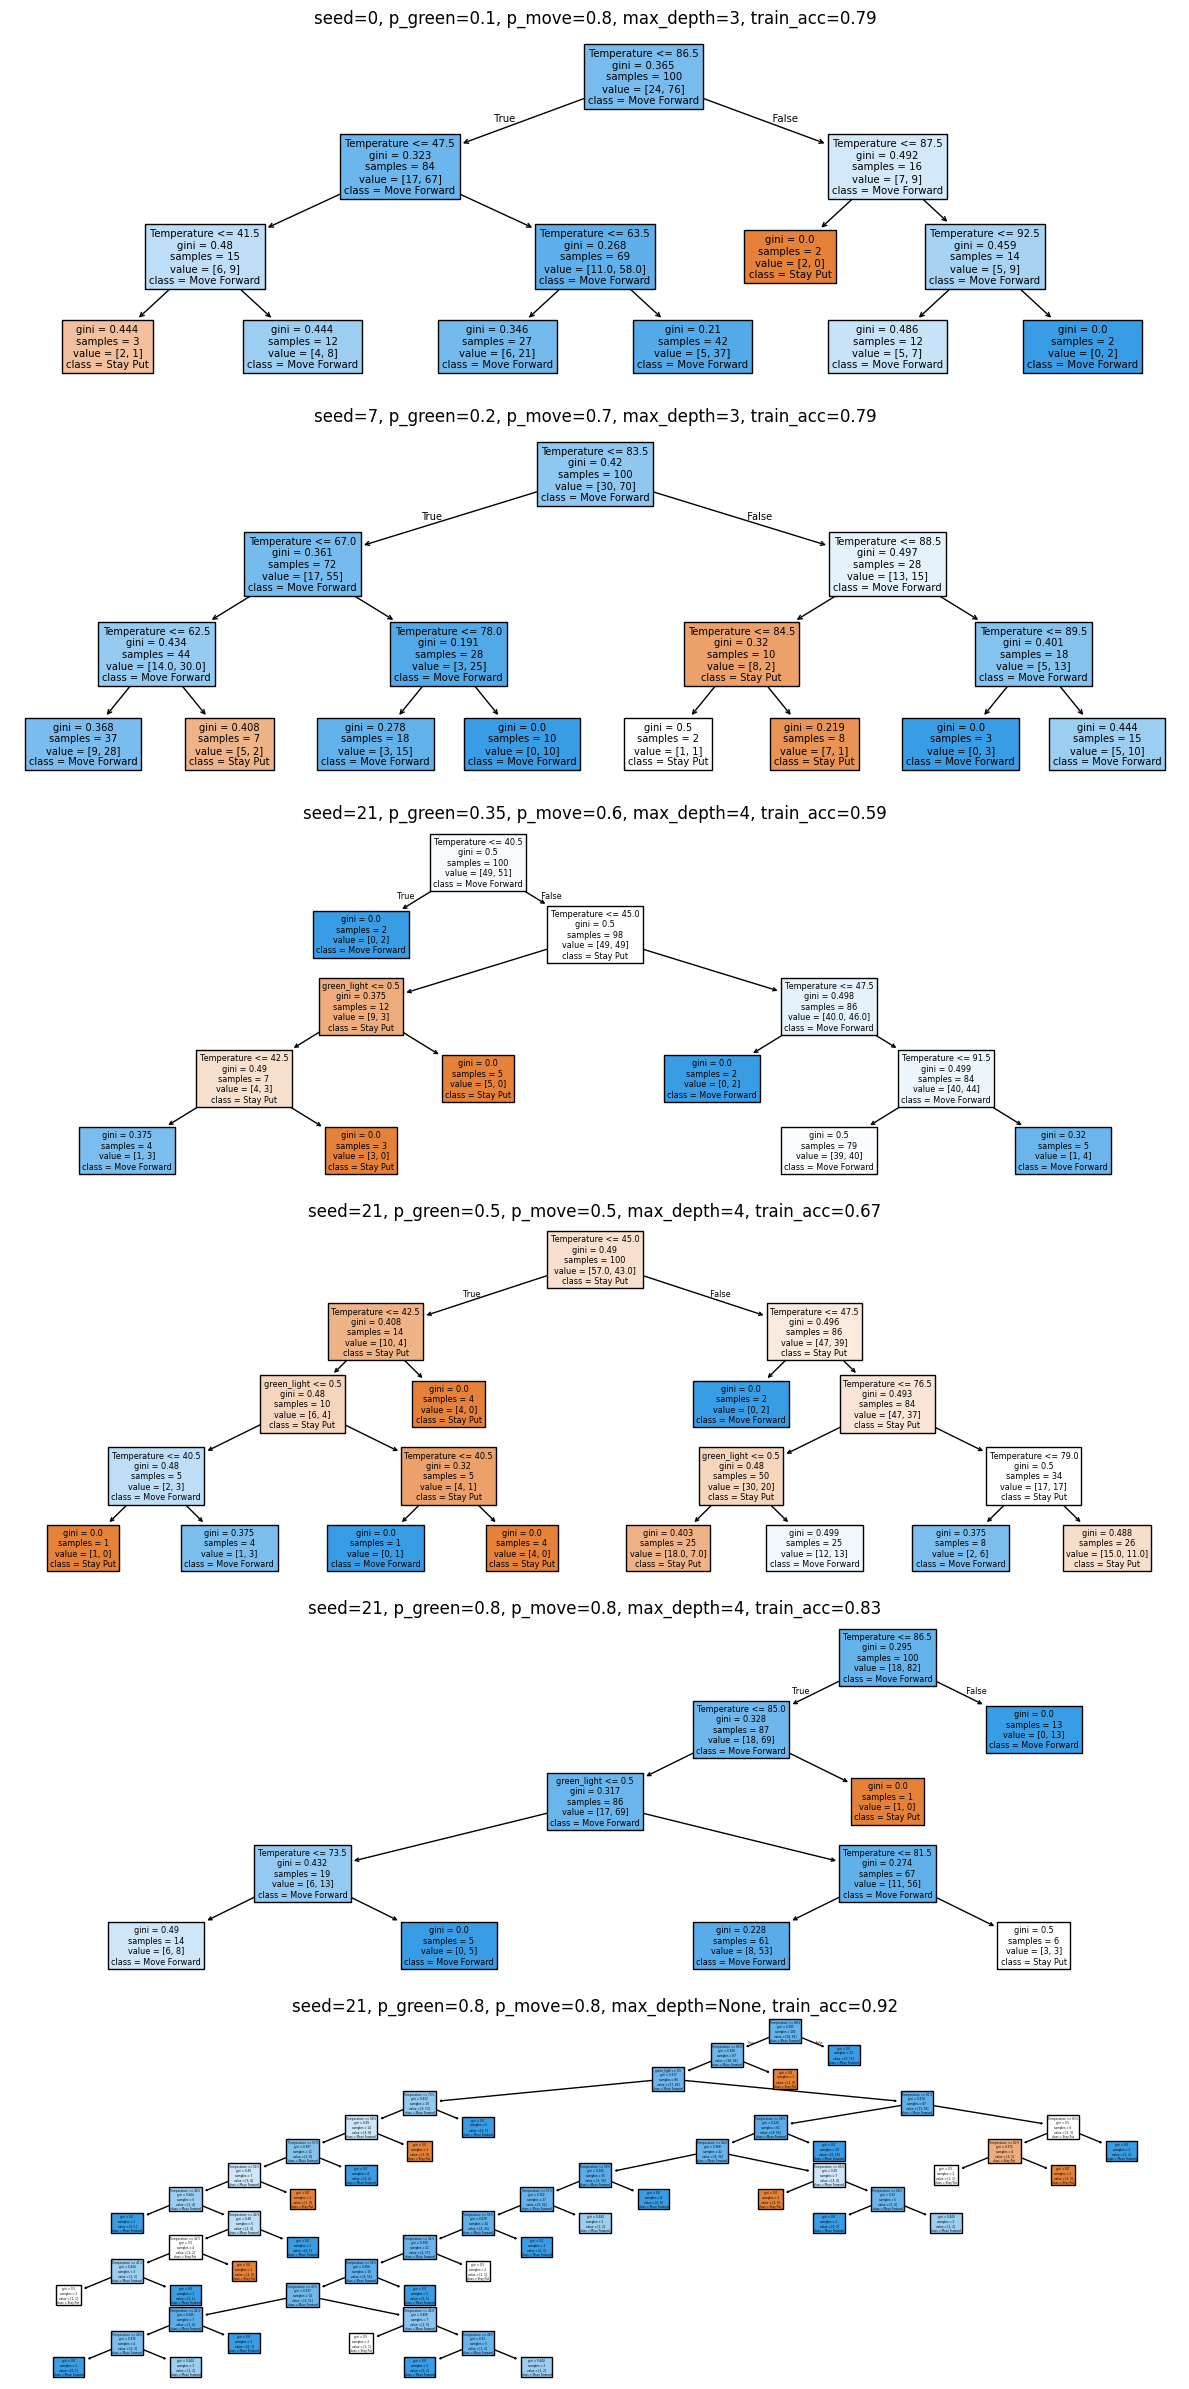

In [48]:
#
#
# Attribution:
# genAI via microsoft copilot
# 


# Try multiple synthetic-data setups, train a tree for each, and visualize
scenarios = [
  {"seed": 0, "p_green": 0.10, "p_move": 0.80, "max_depth": 3},
  {"seed": 7, "p_green": 0.20, "p_move": 0.70, "max_depth": 3},
  {"seed": 21, "p_green": 0.35, "p_move": 0.60, "max_depth": 4},
  {"seed": 21, "p_green": 0.5, "p_move": 0.5, "max_depth": 4},
  {"seed": 21, "p_green": 0.8, "p_move": 0.8, "max_depth": 4},
  {"seed": 21, "p_green": 0.8, "p_move": 0.8, "max_depth": None},
]

results = []
models = []

fig, axes = plt.subplots(len(scenarios), 1, figsize=(12, 4 * len(scenarios)))
if len(scenarios) == 1:
  axes = [axes]

for i, cfg in enumerate(scenarios):
  rng = np.random.default_rng(cfg["seed"])

  df_syn = pd.DataFrame({
    "green_light": rng.choice([0, 1], size=100, p=[1 - cfg["p_green"], cfg["p_green"]]),
    "Temperature": rng.integers(40, 95, size=100),
  })
  df_syn["move_forward"] = rng.choice([0, 1], size=100, p=[1 - cfg["p_move"], cfg["p_move"]])

  X_syn = df_syn[["green_light", "Temperature"]]
  y_syn = df_syn["move_forward"]

  model = DecisionTreeClassifier(max_depth=cfg["max_depth"], random_state=cfg["seed"])
  model.fit(X_syn, y_syn)

  acc = model.score(X_syn, y_syn)
  results.append({**cfg, "train_accuracy": acc})
  models.append((model, X_syn, y_syn))

  plot_tree(
    model,
    ax=axes[i],
    feature_names=["green_light", "Temperature"],
    class_names=["Stay Put", "Move Forward"],
    filled=True
  )
  axes[i].set_title(
    f"seed={cfg['seed']}, p_green={cfg['p_green']}, p_move={cfg['p_move']}, "
    f"max_depth={cfg['max_depth']}, train_acc={acc:.2f}"
  )

plt.tight_layout()

results_df = pd.DataFrame(results)
display(results_df)

# Optional: dtreeviz for the last model
last_model, last_X, last_y = models[-1]
viz_model = dtreeviz.model(
  last_model,
  X_train=last_X,
  y_train=last_y,
  feature_names=["green_light", "Temperature"],
  target_name="move_forward",
  class_names=["Stay Put", "Move Forward"]
)
viz_model.view()

# Plot by probabilities

## By green light

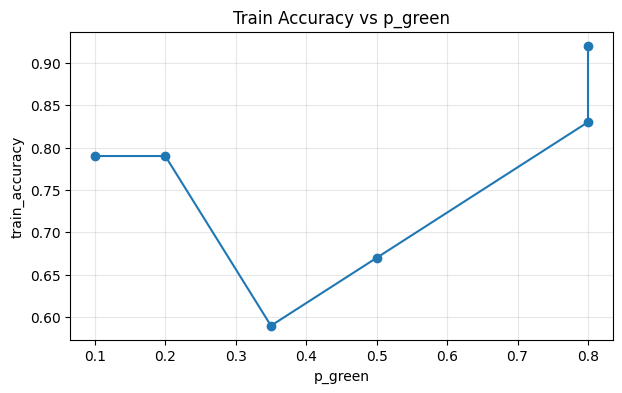

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

res_df = pd.DataFrame(results)

# Example 1: curve of p_move vs train_accuracy
curve_df = res_df.sort_values("p_green")
plt.figure(figsize=(7,4))
plt.plot(curve_df["p_green"], curve_df["train_accuracy"], marker="o")
plt.xlabel("p_green")
plt.ylabel("train_accuracy")
plt.title("Train Accuracy vs p_green")
plt.grid(True, alpha=0.3)
plt.show()

## By Move

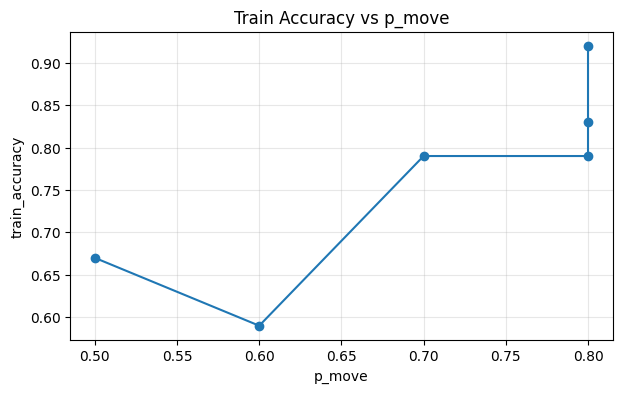

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

res_df = pd.DataFrame(results)

# Example 1: curve of p_move vs train_accuracy
curve_df = res_df.sort_values("p_move")
plt.figure(figsize=(7,4))
plt.plot(curve_df["p_move"], curve_df["train_accuracy"], marker="o")
plt.xlabel("p_move")
plt.ylabel("train_accuracy")
plt.title("Train Accuracy vs p_move")
plt.grid(True, alpha=0.3)
plt.show()

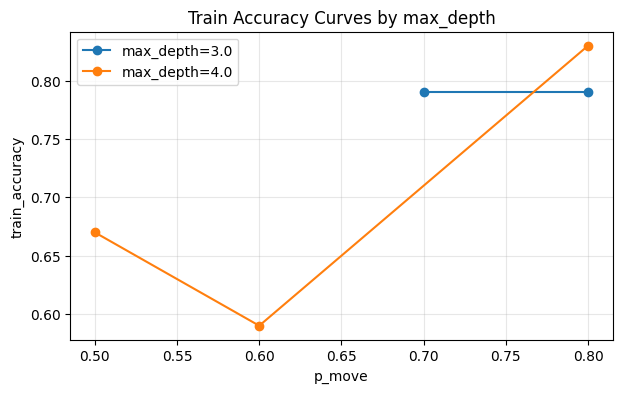

In [51]:
plt.figure(figsize=(7,4))
for d, g in results_df.groupby("max_depth"):
    g = g.sort_values("p_move")
    plt.plot(g["p_move"], g["train_accuracy"], marker="o", label=f"max_depth={d}")

plt.xlabel("p_move")
plt.ylabel("train_accuracy")
plt.title("Train Accuracy Curves by max_depth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## By both green light and move

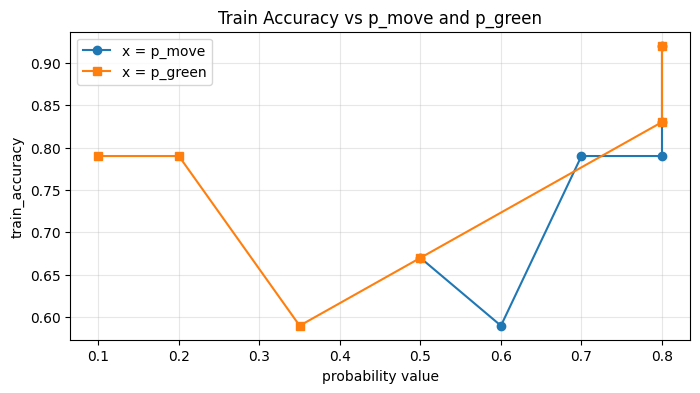

In [52]:
import matplotlib.pyplot as plt

curve_move = res_df.sort_values("p_move")
curve_green = res_df.sort_values("p_green")

plt.figure(figsize=(8, 4))
plt.plot(curve_move["p_move"], curve_move["train_accuracy"], marker="o", label="x = p_move")
plt.plot(curve_green["p_green"], curve_green["train_accuracy"], marker="s", label="x = p_green")

plt.xlabel("probability value")
plt.ylabel("train_accuracy")
plt.title("Train Accuracy vs p_move and p_green")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

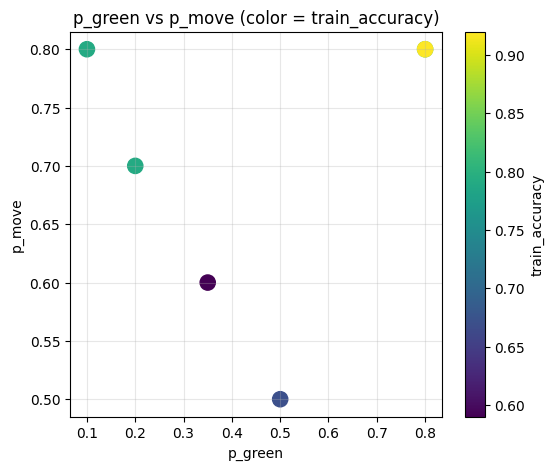

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

res_df = pd.DataFrame(results)

# 2D scatter with accuracy as color
plt.figure(figsize=(6,5))
sc = plt.scatter(
    res_df["p_green"],
    res_df["p_move"],
    c=res_df["train_accuracy"],
    s=120,
    cmap="viridis"
)
plt.xlabel("p_green")
plt.ylabel("p_move")
plt.title("p_green vs p_move (color = train_accuracy)")
plt.colorbar(sc, label="train_accuracy")
plt.grid(True, alpha=0.3)
plt.show()

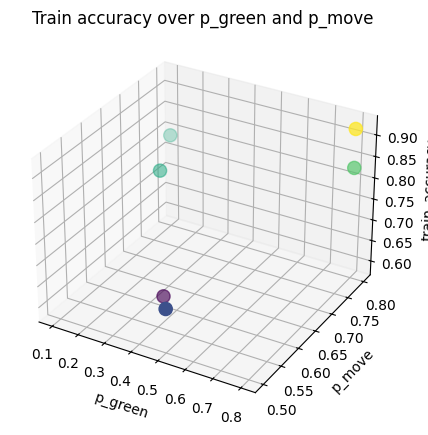

In [54]:
# 3D scatter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    res_df["p_green"],
    res_df["p_move"],
    res_df["train_accuracy"],
    c=res_df["train_accuracy"],
    cmap="viridis",
    s=90
)
ax.set_xlabel("p_green")
ax.set_ylabel("p_move")
ax.set_zlabel("train_accuracy")
ax.set_title("Train accuracy over p_green and p_move")
plt.show()

# References

## Generating synthetic data
https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html
https://medium.com/@24littledino/choice-in-numpy-4a39a715df3e
https://www.codecademy.com/resources/docs/numpy/random-module/choice

### With Generator and Seed for Reproducibility
https://numpy.org/doc/stable/reference/random/index.html
https://medium.com/@prathik.codes/understanding-numpy-random-number-generator-rng-class-and-its-machine-learning-applications-c2020005e274

## Training a DecisionTreeClassifier
https://scikit-learn.org/stable/modules/tree.html#tree
https://www.kaggle.com/code/residentmario/decision-trees-with-animal-shelter-outcomes
https://www.linkedin.com/pulse/basics-decision-tree-python-omkar-sutar/
https://scikit-learn.org/stable/auto_examples/tree/plot_iris_dtc.html
https://arounddatascience.com/blog/artificial-intelligence/decision-tree-classification-in-python-a-complete-beginner-friendly-guide/
https://medium.com/@francescofranco_39234/decision-trees-in-machine-learning-5e21a8446749


## Visualize
https://mljar.com/blog/visualize-decision-tree/

## Understanding Plot Tree output
https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html


## Using dtreeviz
Remember to install `brew install graphviz` to avoid odd errors e.g. `ExecutableNotFound: failed to execute 'dot', make sure the Graphviz executables are on your systems' PATH`. 
https://github.com/parrt/dtreeviz/blob/master/notebooks/dtreeviz_sklearn_visualisations.ipynb
https://explained.ai/decision-tree-viz/index.html




